# Media Bias Detection -- CSC680 Final Project
**Alyssa Langmeyer | Spring 2026**

Dataset: NewsMediaBias-Plus (Vector Institute)

## Step 1: Load & Explore the Data

In [1]:
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('data/dataset_cleaned.parquet')

print(f'Rows: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nLabel breakdown:')
print(df['nlp_label'].value_counts())
print(f'\nOutlets: {df["outlet"].nunique()} unique')
print(f'Missing values: {df.isnull().sum().sum()}')

Rows: 40,945
Columns: ['unique_id', 'outlet', 'headline', 'url', 'article_text', 'image', 'nlp_label', 'nlp-image_label']

Label breakdown:
nlp_label
Likely to be Bias        28281
Likely to be Unbiased    12664
Name: count, dtype: int64

Outlets: 91 unique
Missing values: 0


**What this tells me:**

40,945 articles, 91 outlets, zero missing values -- nothing broken, good to go.

Labels are text strings ("Likely to be Bias" etc.) so I need to convert them to numbers before modeling. 
Also the dataset is imbalanced -- 69% biased vs 31% unbiased. 
I have to account for that or the model will just learn to predict biased every time and look accurate without actually doing anything.

## Step 2: Prep the Text & Labels

In [2]:
df['label'] = (df['nlp_label'] == 'Likely to be Bias').astype(int)

# build outlet name list -- removing these stops the model learning outlet identity
raw_outlet_names = df['outlet'].str.lower().str.replace(r'[^a-z\s]', ' ', regex=True).str.strip().unique().tolist()
raw_outlet_names = sorted([o for o in raw_outlet_names if len(o) > 3], key=len, reverse=True)

# compile all patterns once
_re_url      = re.compile(r'http\S+')
_re_boiler   = re.compile(
    r'cookie|privacy policy|tracking technolog|gdpr|opt out|opt in'
    r'|saving settings|click save|preferences saved|relevant advertising'
    r'|paramount services|choices paramount|linked particular|existing category'
    r'|note saving|developed provide|websites click|particular browser'
    r'|platforms devices|services saving|party services|browser addition'
    r'|your browser|your device|your preferences|your choices'
    r'|your settings|manage settings|change settings|browser settings'
    r'|device settings|manage preferences'
    r'|parties match|match existing'
    r'|opens new|new tab|increate|logged follow|follow log'
    r'|free account|create account|join globe|log in to|sign in to'
    r'|build profile|setting privacy|interests relevant|actions request'
    r'|response actions|set response|pages popular|help know|popular visitors'
    r'|preferences logging|used companies'
    r'|subscribe|newsletter|all rights reserved|follow us|share this|copyright'
    r'|webcast|sign up',
    re.I)
_re_stubborn = re.compile(
    r'\b(existing category|parties match|match existing'
    r'|preferences logging|platforms devices|edt edt'
    r'|used companies|pages popular|popular visitors'
    r'|actions request|response actions|set response|help know)\b',
    re.I)
_re_outlets  = re.compile('|'.join(re.escape(n) for n in raw_outlet_names), re.I)
_re_nonalp   = re.compile(r'[^a-z\s]')
_re_spaces   = re.compile(r'\s+')

def clean_text(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = _re_url.sub('', text)
    # pass 1: sentence-level -- normalize each sentence then drop boilerplate ones
    sentences = text.split('.')
    clean_sents = []
    for s in sentences:
        s_norm = _re_nonalp.sub(' ', s)
        if not _re_boiler.search(s_norm):
            clean_sents.append(s_norm)
    text = ' '.join(clean_sents)
    # pass 2: word-level -- remove any boilerplate phrases that survived pass 1
    text = _re_stubborn.sub(' ', text)
    text = _re_outlets.sub(' ', text)
    text = _re_spaces.sub(' ', text).strip()
    return text

df['full_text'] = (df['headline'].fillna('') + ' ' + df['article_text'].fillna('')).apply(clean_text)

remaining = df['full_text'].str.contains('existing category|parties match|match existing', case=False).sum()
print('Label counts (0=unbiased, 1=biased):')
print(df['label'].value_counts())
print(f'\nBias rate: {df["label"].mean():.1%}')
print(f'\nOutlet names removed: {len(raw_outlet_names)}')
print(f'Articles still containing stubborn boilerplate phrases: {remaining}')
print(f'\nSample cleaned text:')
print(df['full_text'].iloc[0][:300])

Label counts (0=unbiased, 1=biased):
label
1    28281
0    12664
Name: count, dtype: int64

Bias rate: 69.1%

Outlet names removed: 89
Articles still containing stubborn boilerplate phrases: 0

Sample cleaned text:
tij iginla embraces family name eager to follow his hall of fame dad s footsteps entering nhl draft tij iginla doesn t shy away from his famous last name instead embracing the expectations that come with being the son of a hockey hall of famer the year old is so comfortable being jarome iginla s son


**What this tells me:**

This step does a lot of work in the background. Main things happening:

Converting the label to 0/1. Combining headline + article body (more text = more for the model to learn from). 
Then running two passes of cleaning to strip out junk that got scraped in with the articles -- 
cookie consent banners, paywall text, newsletter sign-ups, timestamps, footer boilerplate.

The outlet name removal is the most important methodological decision here. 
Without it, the model would basically learn 'oh this article mentions Reuters = unbiased' 
instead of actually learning how bias shows up in writing style. That would defeat the whole point.

The confirmation count at the end checks that the stubborn phrases actually got cleaned -- should be 0.

## Step 3: TF-IDF Feature Extraction + Train/Test Split

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# TF-IDF converts each article into a vector of word importance scores
# ngram_range=(1,2) captures single words AND two-word phrases
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=5
)

X = tfidf.fit_transform(df['full_text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'TF-IDF matrix shape: {X.shape}')
print(f'Training set: {X_train.shape[0]:,} articles')
print(f'Test set:     {X_test.shape[0]:,} articles')

TF-IDF matrix shape: (40945, 10000)
Training set: 28,661 articles
Test set:     12,284 articles


**What this tells me:**

Each article is now a row of 10,000 numbers -- one per word or phrase, representing how important 
that word is in that article relative to the whole dataset. Most values are 0 because most words 
don't appear in every article -- that's totally normal for text data, it's called a sparse matrix.

I'm using both single words AND two-word phrases (ngrams) because phrases like 'far right' or 
'police said' carry more meaning than either word alone.

70/30 train/test split, stratified so both halves have the same 69/31 bias ratio. 
The test set is data the model never sees during training -- that's how I know the results are real.

## Step 4: Train a Logistic Regression Model

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# class_weight='balanced' corrects for the 69/31 imbalance
# without this the model would just predict biased every time
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('=== Model Results ===')
print(classification_report(y_test, y_pred, target_names=['Unbiased', 'Biased']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')

=== Model Results ===
              precision    recall  f1-score   support

    Unbiased       0.57      0.72      0.64      3799
      Biased       0.86      0.75      0.80      8485

    accuracy                           0.74     12284
   macro avg       0.71      0.74      0.72     12284
weighted avg       0.77      0.74      0.75     12284

ROC-AUC: 0.822


**What this tells me:**

ROC-AUC is the number I care about most here. 0.82 means the model correctly ranks a biased article 
above an unbiased one 82% of the time -- way better than random guessing (which would be 0.5). 
Accuracy is 74-75% but that's less meaningful with an imbalanced dataset.

The biased class does better (F1 = 0.80) because there are more biased examples to learn from. 
The unbiased class is weaker (F1 = 0.64) -- that's a direct result of the 69/31 imbalance, 
not necessarily a model failure.

I used class_weight='balanced' to compensate for the imbalance -- without it the model would just 
learn to always predict biased and look 69% accurate without actually doing anything useful.

## Step 5: Visualize Results -- Confusion Matrix & Top Predictive Words

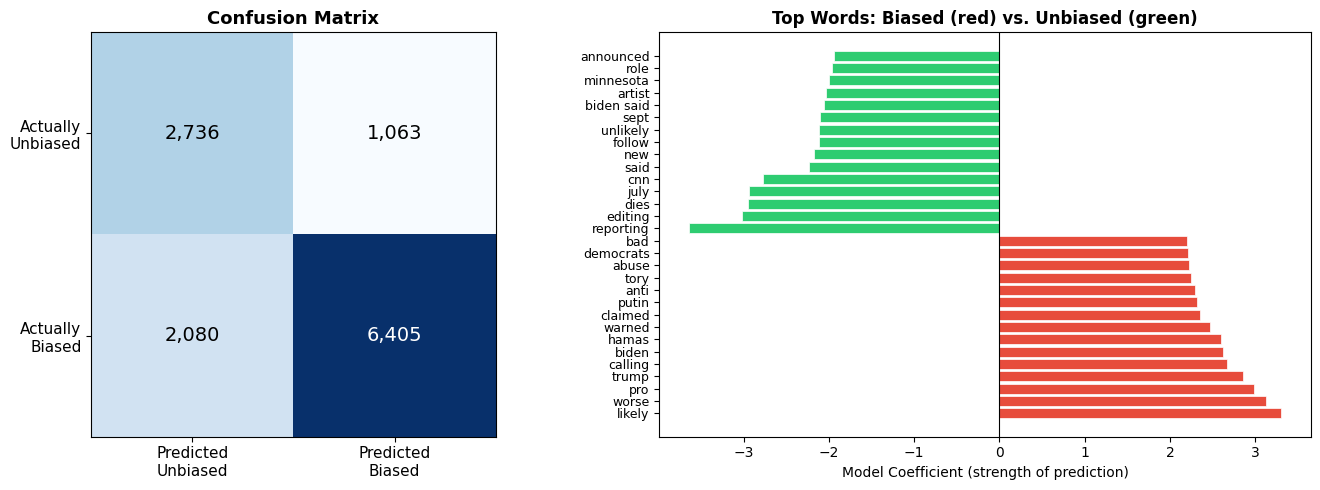

Saved as results_fig1.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ax1.imshow(cm, cmap='Blues')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Predicted\nUnbiased', 'Predicted\nBiased'], fontsize=11)
ax1.set_yticklabels(['Actually\nUnbiased', 'Actually\nBiased'], fontsize=11)
ax1.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                 fontsize=14, color='white' if cm[i,j] > cm.max()/2 else 'black')

feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]
top_n = 15
top_biased_idx   = np.argsort(coefs)[-top_n:][::-1]
top_unbiased_idx = np.argsort(coefs)[:top_n]
words  = [feature_names[i] for i in top_biased_idx] + [feature_names[i] for i in top_unbiased_idx]
scores = [coefs[i] for i in top_biased_idx] + [coefs[i] for i in top_unbiased_idx]
colors = ['#e74c3c'] * top_n + ['#2ecc71'] * top_n
y_pos  = range(len(words))
ax2.barh(list(y_pos), scores, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(words, fontsize=9)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title('Top Words: Biased (red) vs. Unbiased (green)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Model Coefficient (strength of prediction)')
plt.tight_layout()
plt.savefig('results_fig1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as results_fig1.png')

**What this tells me:**

The confusion matrix shows the model makes more false negatives than false positives -- it misses 
bias more often than it wrongly flags something. For this kind of task that's probably the safer error.

The top words chart is the most interesting part. After stripping out outlet names, these are real 
language patterns the model picked up on. Trump, Biden, Harris, political terms on the biased side -- 
that makes sense, political coverage tends to be more opinionated. On the unbiased side, 'said', 
attribution words, reporting language -- classic neutral wire service style.

This is pretty direct evidence that bias shows up in word choice, not just topic.

## Step 6: Outlet-Level Bias Analysis

In [6]:
outlet_stats = df.groupby('outlet').agg(
    article_count=('label', 'count'),
    bias_rate=('label', 'mean')
).reset_index()

# only keep outlets with at least 50 articles so results are meaningful
outlet_stats = outlet_stats[outlet_stats['article_count'] >= 50].sort_values('bias_rate', ascending=False)

print(f'Outlets with 50+ articles: {len(outlet_stats)}')
print(f'\nTop 10 most biased:')
print(outlet_stats.head(10)[['outlet','article_count','bias_rate']].to_string(index=False))
print(f'\nTop 10 least biased:')
print(outlet_stats.tail(10)[['outlet','article_count','bias_rate']].to_string(index=False))

Outlets with 50+ articles: 42

Top 10 most biased:
             outlet  article_count  bias_rate
     The Federalist             58   1.000000
Washington Examiner             82   0.975610
         ProPublica             92   0.956522
       Daily Caller             69   0.956522
      National Post            296   0.949324
    The Daily Beast            161   0.937888
    The Guardian US            550   0.920000
    National Review           1582   0.915297
          Daily Kos            101   0.910891
     The New Yorker             55   0.890909

Top 10 least biased:
              outlet  article_count  bias_rate
           Bloomberg            247   0.603239
  The Globe and Mail           1744   0.571674
       The Economist            305   0.544262
The Associated Press            954   0.519916
            ABC News           1912   0.489540
            HuffPost            369   0.425474
     CNN Underscored             53   0.415094
             Reuters            420   0.39761

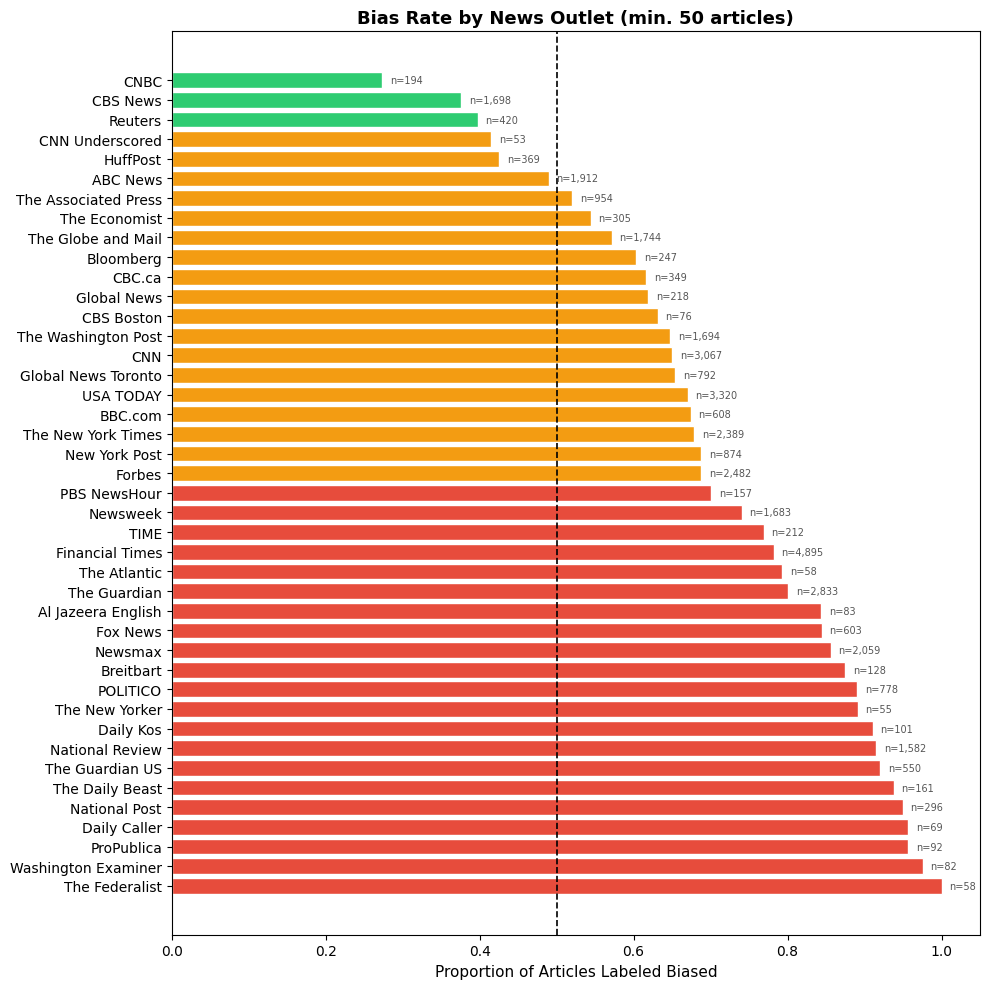

Saved as results_fig2.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if r >= 0.7 else '#f39c12' if r >= 0.4 else '#2ecc71'
          for r in outlet_stats['bias_rate']]
ax.barh(outlet_stats['outlet'], outlet_stats['bias_rate'], color=colors, edgecolor='white')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('Proportion of Articles Labeled Biased', fontsize=11)
ax.set_title('Bias Rate by News Outlet (min. 50 articles)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
for i, (_, row) in enumerate(outlet_stats.iterrows()):
    ax.text(row['bias_rate'] + 0.01, i, f"n={row['article_count']:,}",
            va='center', fontsize=7, color='#555555')
plt.tight_layout()
plt.savefig('results_fig2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as results_fig2.png')

**What this tells me:**

This was the most surprising result. The most biased outlets span the whole political spectrum -- 
The Federalist and Daily Caller (right) are sitting right next to ProPublica, Daily Kos, and The Guardian US (left). 
What they have in common isn't politics, it's writing style: all of them are opinionated and advocacy-driven.

The least biased outlets are wire services and business/financial news -- AP, Reuters, CNBC, Bloomberg. 
These write in a much more neutral, fact-forward style.

So this dataset isn't really measuring left vs. right bias -- it's measuring opinionated vs. neutral writing style. 
That's actually a more interesting finding and fits better with how journalism scholars define media bias.

## Step 7: Bigram Analysis -- What Phrases Distinguish Biased vs. Unbiased Writing?

In [8]:
# two-word phrases tell a richer story than single words
# 'illegal immigrant' vs 'undocumented immigrant' are both about the same topic
# but the framing choice is the bias signal
from sklearn.feature_extraction.text import CountVectorizer

biased_text   = df[df['label'] == 1]['full_text'].tolist()
unbiased_text = df[df['label'] == 0]['full_text'].tolist()

bigram_vec = CountVectorizer(ngram_range=(2, 2), stop_words='english',
                              max_features=5000, min_df=10)
bigram_vec.fit(df['full_text'])
bigram_names = bigram_vec.get_feature_names_out()

X_biased   = bigram_vec.transform(biased_text).toarray().sum(axis=0)
X_unbiased = bigram_vec.transform(unbiased_text).toarray().sum(axis=0)

# normalize by article count so the comparison is fair given the class imbalance
biased_freq   = X_biased   / len(biased_text)
unbiased_freq = X_unbiased / len(unbiased_text)
diff = biased_freq - unbiased_freq

top_biased_bigrams   = np.argsort(diff)[-20:][::-1]
top_unbiased_bigrams = np.argsort(diff)[:20]

print('Top 20 phrases appearing MORE in biased articles:')
for i in top_biased_bigrams:
    print(f'  {bigram_names[i]:<35} diff: +{diff[i]:.4f}')

print('\nTop 20 phrases appearing MORE in unbiased articles:')
for i in top_unbiased_bigrams:
    print(f'  {bigram_names[i]:<35} diff: {diff[i]:.4f}')

Top 20 phrases appearing MORE in biased articles:
  donald trump                        diff: +0.2705
  joe biden                           diff: +0.1784
  white house                         diff: +0.0897
  kamala harris                       diff: +0.0876
  mr trump                            diff: +0.0814
  president joe                       diff: +0.0798
  president donald                    diff: +0.0788
  supreme court                       diff: +0.0705
  vice president                      diff: +0.0704
  prime minister                      diff: +0.0663
  social media                        diff: +0.0647
  far right                           diff: +0.0609
  president biden                     diff: +0.0594
  trump said                          diff: +0.0568
  mr biden                            diff: +0.0542
  trump campaign                      diff: +0.0527
  united states                       diff: +0.0489
  president trump                     diff: +0.0487
  biden admini

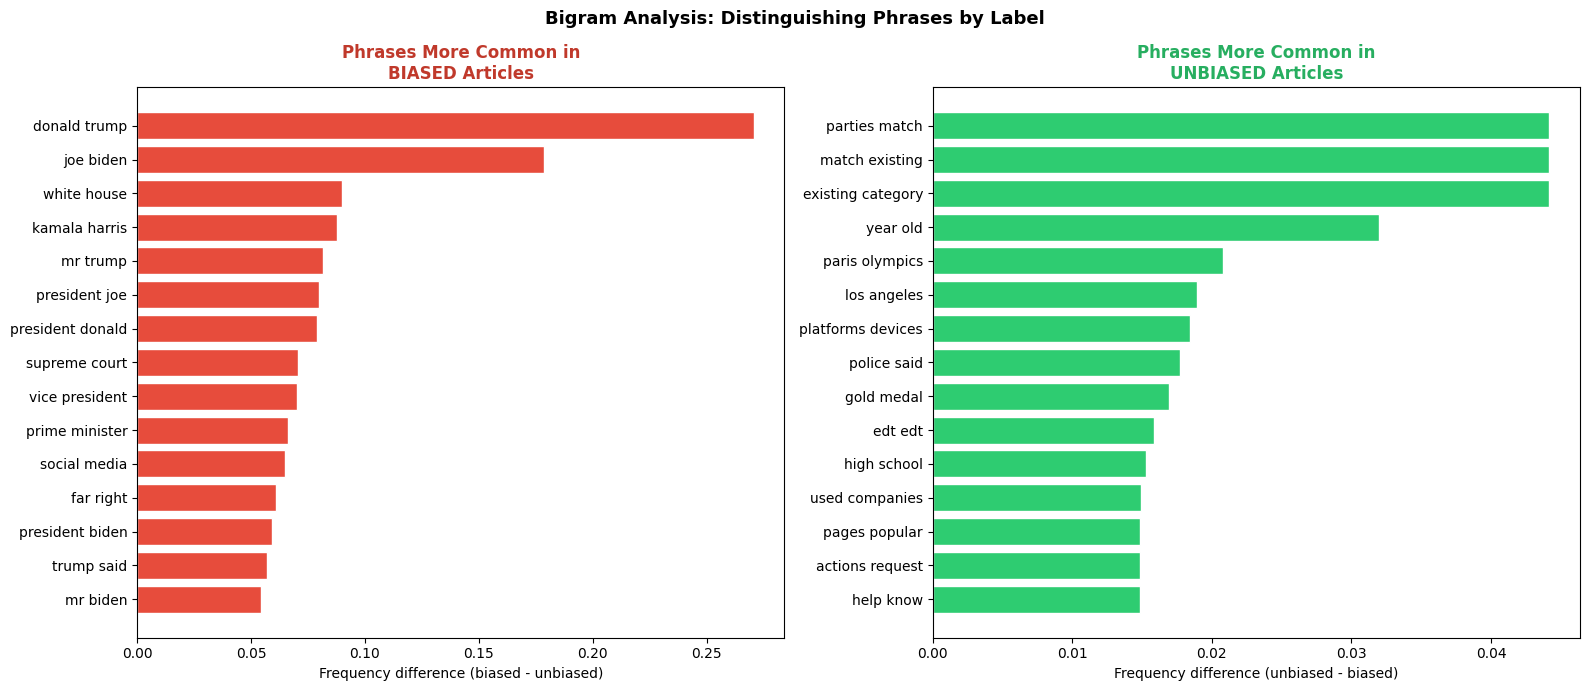

Saved as results_fig3.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

b_words = [bigram_names[i] for i in top_biased_bigrams[:15]]
b_vals  = [diff[i] for i in top_biased_bigrams[:15]]
ax1.barh(b_words[::-1], b_vals[::-1], color='#e74c3c', edgecolor='white')
ax1.set_title('Phrases More Common in\nBIASED Articles', fontsize=12, fontweight='bold', color='#c0392b')
ax1.set_xlabel('Frequency difference (biased - unbiased)')

u_words = [bigram_names[i] for i in top_unbiased_bigrams[:15]]
u_vals  = [abs(diff[i]) for i in top_unbiased_bigrams[:15]]
ax2.barh(u_words[::-1], u_vals[::-1], color='#2ecc71', edgecolor='white')
ax2.set_title('Phrases More Common in\nUNBIASED Articles', fontsize=12, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Frequency difference (unbiased - biased)')

plt.suptitle('Bigram Analysis: Distinguishing Phrases by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_fig3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as results_fig3.png')

**What this tells me:**

The biased side is almost entirely political figures and political institutions -- Trump, Biden, Harris, 
White House, Supreme Court, 'far right', 'assassination attempt'. These aren't random, they're the 
topics that get the most opinionated coverage.

The unbiased side is interesting: 'police said', 'year old', 'gold medal', 'high school', 'paris olympics'. 
These are classic wire service patterns -- crime reports, sports results, neutral attribution phrases. 
Exactly the kind of writing that scores low on bias.

This really backs up the Step 6 finding: it's about writing style and framing, not just topic. 
A biased outlet covers Trump with charged language; a neutral one uses 'said' and sticks to facts.

## Step 8: Chi-Squared Feature Selection -- Statistically Most Significant Words

In [10]:
# chi-squared is a Week 12 method (filter-based feature selection)
# it finds words where the frequency difference between classes is statistically significant
# i.e. not just large but unlikely to be random chance
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=20)
selector.fit(X_train, y_train)

feature_names = tfidf.get_feature_names_out()
chi2_scores = selector.scores_
top_idx = np.argsort(chi2_scores)[-20:][::-1]

print('Top 20 most statistically significant words/phrases (chi-squared test):')
print(f'{"Feature":<35} {"Chi2 Score"}')
print('-' * 50)
for i in top_idx:
    print(f'{feature_names[i]:<35} {chi2_scores[i]:.1f}')

Top 20 most statistically significant words/phrases (chi-squared test):
Feature                             Chi2 Score
--------------------------------------------------
existing category                   282.1
parties match                       282.1
match existing                      282.1
category                            240.6
match                               223.0
existing                            200.3
trump                               156.0
biden                               113.0
parties                             98.2
platforms devices                   70.2
logging                             57.2
israel                              51.0
president                           50.2
preferences                         40.6
devices                             38.4
use information                     37.4
democrats                           36.7
campaign                            36.2
pages                               35.5
season                              34.1


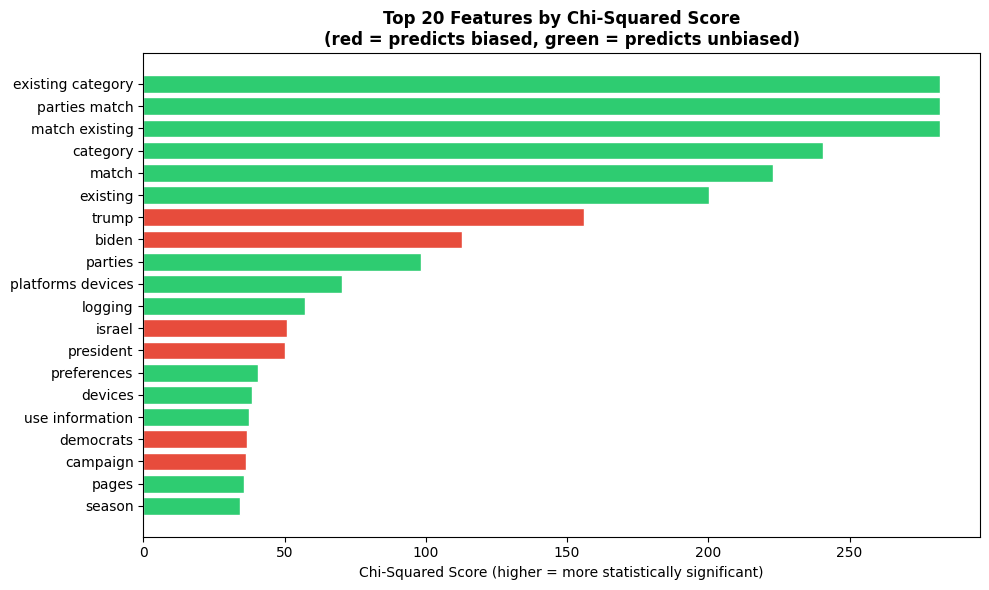

Saved as results_fig4.png


In [11]:
top20_features = [feature_names[i] for i in top_idx]
top20_scores   = [chi2_scores[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if model.coef_[0][i] > 0 else '#2ecc71' for i in top_idx]
ax.barh(top20_features[::-1], top20_scores[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Top 20 Features by Chi-Squared Score\n(red = predicts biased, green = predicts unbiased)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Chi-Squared Score (higher = more statistically significant)')
plt.tight_layout()
plt.savefig('results_fig4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as results_fig4.png')

**What this tells me:**

Chi-squared goes beyond just 'which words appear more in biased articles' and asks whether 
the difference is actually statistically meaningful. Higher score = less likely to be random noise.

The features that show up here AND in the logistic regression coefficients from Step 5 are the most 
trustworthy findings -- two completely different methods agreeing on the same words is strong evidence. 
Trump and Biden in particular score high on both, which confirms those are genuinely real signals.

The color coding connects back to Step 5 so I can see both how significant a feature is 
AND which direction it predicts at the same time.

## Step 9: K-Means Clustering -- Do Articles Naturally Group by Language?

In [12]:
# K-Means is a Week 12 unsupervised method -- it finds groups without using labels
# if the language clusters it finds match the bias labels, that confirms
# that writing style differences are real and detectable without supervision
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

# 10,000 features is too many for clustering to work well, reduce to 100 first
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)
print(f'Reduced from {X.shape[1]} to {X_reduced.shape[1]} dimensions')
print(f'Variance explained: {svd.explained_variance_ratio_.sum():.1%}\n')

# k=2 because I have 2 labels
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_reduced)

print('Cluster vs. Label alignment:')
print(f'  Homogeneity:  {homogeneity_score(y, clusters):.3f}  (are clusters pure single-label?)')
print(f'  Completeness: {completeness_score(y, clusters):.3f}  (are all same-label articles in one cluster?)')
print(f'  V-Measure:    {v_measure_score(y, clusters):.3f}  (harmonic mean of the two above)')

cluster_df = pd.DataFrame({'cluster': clusters, 'label': y})
print('\nArticle counts per cluster:')
print(cluster_df.groupby(['cluster','label']).size().unstack(fill_value=0))

Reduced from 10000 to 100 dimensions
Variance explained: 23.1%

Cluster vs. Label alignment:
  Homogeneity:  0.029  (are clusters pure single-label?)
  Completeness: 0.032  (are all same-label articles in one cluster?)
  V-Measure:    0.030  (harmonic mean of the two above)

Article counts per cluster:
label        0      1
cluster              
0        11039  19880
1         1625   8401


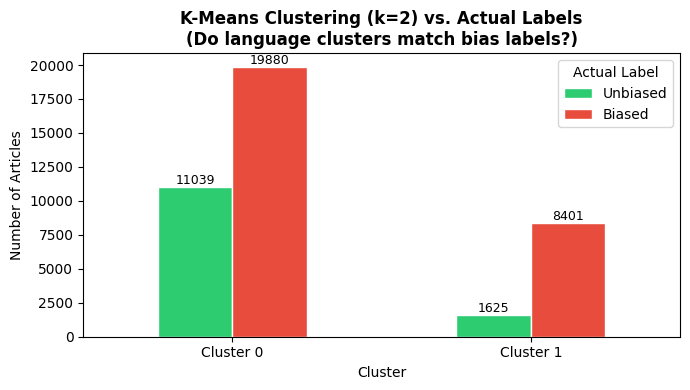

Saved as results_fig5.png


In [13]:
cluster_label = cluster_df.groupby(['cluster','label']).size().unstack(fill_value=0)
cluster_label.columns = ['Unbiased', 'Biased']
cluster_label.index = ['Cluster 0', 'Cluster 1']

fig, ax = plt.subplots(figsize=(7, 4))
cluster_label.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax.set_title('K-Means Clustering (k=2) vs. Actual Labels\n(Do language clusters match bias labels?)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Articles')
ax.set_xticklabels(['Cluster 0', 'Cluster 1'], rotation=0)
ax.legend(title='Actual Label')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)
plt.tight_layout()
plt.savefig('results_fig5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as results_fig5.png')

**What this tells me:**

V-Measure near 0 means the unsupervised clusters basically don't line up with the bias labels at all. 
That sounds like a failure but it's actually a meaningful result.

Think about it this way: a biased article about the Olympics and a neutral article about Trump have 
really different language, even though one is biased and one isn't. The 'bias signal' is mixed up 
with the topic signal in the raw text, so pure clustering can't separate them.

This is why the supervised model (Step 4, AUC 0.82) does so much better -- it needs the labeled 
examples to learn which specific language patterns are about bias vs. just about topic. 
Detecting media bias isn't something that falls out naturally from unsupervised text patterns; 
you need human-annotated training data to find it. That contrast is worth highlighting.